# Lab 05 – Image Segmentation


In [1]:
import os, urllib.request, zipfile
from collections import deque
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
OUT = "outputs"; os.makedirs(OUT, exist_ok=True)

RAW = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/"

def fetch(name, urls):
    """Download an image once; try several mirrors."""
    if os.path.exists(name) and cv2.imread(name) is not None:
        return name
    opener = urllib.request.build_opener()
    opener.addheaders = [("User-Agent", "Mozilla/5.0")]
    urllib.request.install_opener(opener)
    for u in urls:
        try:
            urllib.request.urlretrieve(u, name)
            if cv2.imread(name) is not None:
                return name
        except Exception as e:
            print("  failed:", u, "->", type(e).__name__)
    raise FileNotFoundError(f"Could not download {name}. Upload it manually to the Colab file panel.")

fetch("sudoku.png",  [RAW + "sudoku.png"])
fetch("smarties.png", [RAW + "smarties.png"])
fetch("coins.jpg", [
    "https://raw.githubusercontent.com/opencv/opencv/4.x/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/3.4/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg",
    "https://docs.opencv.org/4.x/water_coins.jpg"])

def rgb(bgr): return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def show(images, titles, cols=None, w=4.2, h=None, save=None, suptitle=None):
    """Grid of images (2-D arrays are shown as gray). Optionally saves the figure."""
    n = len(images); cols = cols or n; rows = int(np.ceil(n / cols))
    h = h or w
    fig, axs = plt.subplots(rows, cols, figsize=(w * cols, h * rows + (0.4 if suptitle else 0)))
    axs = np.atleast_1d(axs).ravel()
    for ax in axs: ax.axis("off")
    for ax, im, t in zip(axs, images, titles):
        if im.ndim == 2: ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        else: ax.imshow(im)
        ax.set_title(t, fontsize=10)
    if suptitle: fig.suptitle(suptitle, fontsize=13, y=1.0)
    plt.tight_layout()
    if save: fig.savefig(os.path.join(OUT, save), dpi=150, bbox_inches="tight")
    plt.show()

def save_img(name, img): cv2.imwrite(os.path.join(OUT, name), img)
print("Setup done. OpenCV", cv2.__version__)

Setup done. OpenCV 4.14.0


---
## Task 1 – Document under uneven lighting: global vs adaptive thresholding

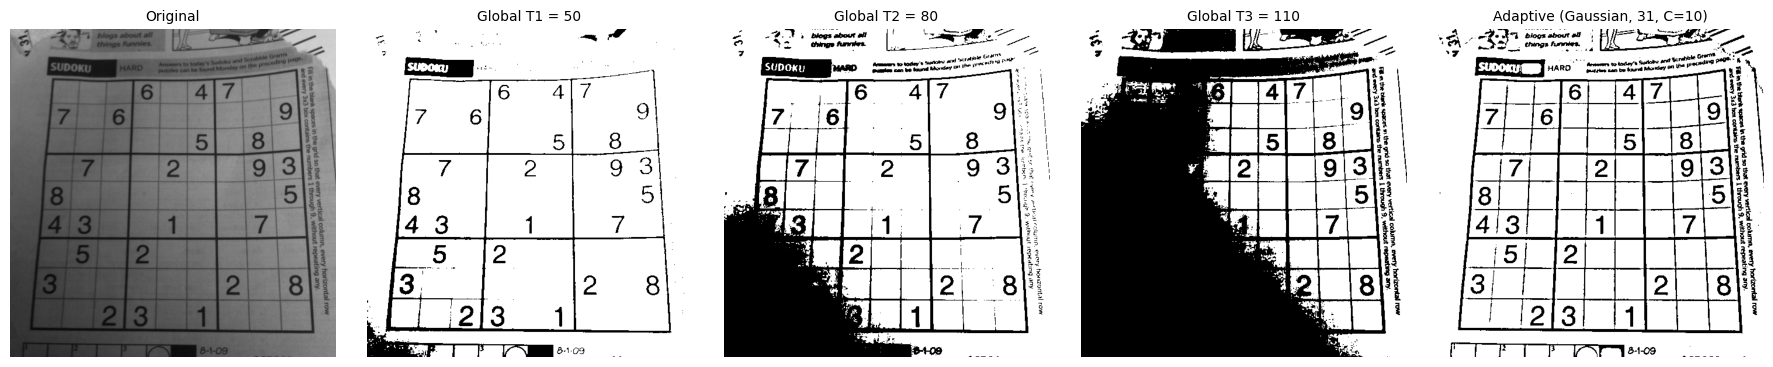

In [2]:
gray = cv2.imread("sudoku.png", cv2.IMREAD_GRAYSCALE)
H, W = gray.shape

# Three global thresholds (dark text -> black, paper -> white)
T_LIST = [50, 80, 110]
glob = [cv2.threshold(gray, t, 255, cv2.THRESH_BINARY)[1] for t in T_LIST]

# Adaptive threshold (Gaussian-weighted local mean, 31x31 window, C = 10)
adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 31, 10)

show([gray] + glob + [adaptive],
     ["Original"] + [f"Global T{i+1} = {t}" for i, t in enumerate(T_LIST)] + ["Adaptive (Gaussian, 31, C=10)"],
     cols=5, w=3.6, save="task1_comparison.png")
save_img("task1_final_adaptive_mask.png", adaptive)

,"tile (row,col)",mean brightness,black% T=50,black% T=80,black% T=110,black% adaptive
0,"(0,0)",100.5,10.2,17.2,63.7,16.1
1,"(0,1)",108.2,4.0,13.1,48.4,17.2
2,"(0,2)",133.8,3.1,9.2,22.1,19.1
3,"(1,0)",82.5,7.9,33.1,100.0,12.0
4,"(1,1)",108.5,7.5,11.7,40.2,15.2
5,"(1,2)",126.0,5.5,10.1,18.8,18.7
6,"(2,0)",59.7,19.1,95.4,100.0,11.1
7,"(2,1)",82.2,12.0,33.4,93.4,15.6
8,"(2,2)",115.6,4.5,8.2,28.2,12.7


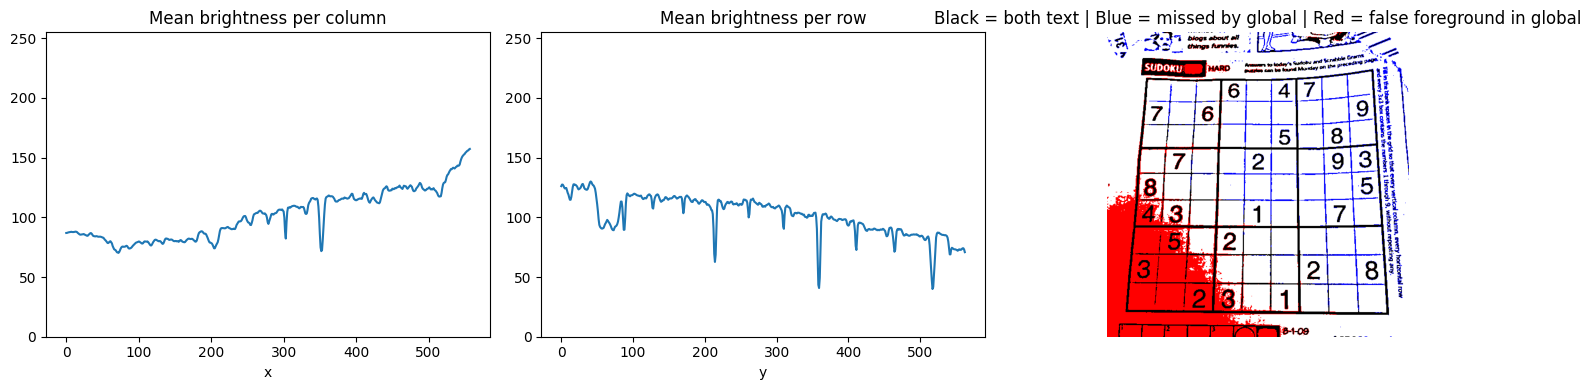

In [3]:
# --- Where does global thresholding fail?  Analyse the image in a 3x3 grid of tiles.
rows_t = []
th, tw = H // 3, W // 3
best_global = glob[1]                      # T2 (80) is the best global result (chosen by inspection) and is used for the comparison
for r in range(3):
    for c in range(3):
        sl = (slice(r*th, (r+1)*th), slice(c*tw, (c+1)*tw))
        rec = {"tile (row,col)": f"({r},{c})", "mean brightness": round(float(gray[sl].mean()), 1)}
        for t, g in zip(T_LIST, glob): rec[f"black% T={t}"] = round(100 * (g[sl] == 0).mean(), 1)
        rec["black% adaptive"] = round(100 * (adaptive[sl] == 0).mean(), 1)
        rows_t.append(rec)
df1 = pd.DataFrame(rows_t); display(df1)

# illumination profile (column-wise mean brightness) + disagreement map between best global and adaptive
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(gray.mean(axis=0)); ax[0].set_title("Mean brightness per column"); ax[0].set_xlabel("x"); ax[0].set_ylim(0, 255)
ax[1].plot(gray.mean(axis=1)); ax[1].set_title("Mean brightness per row");    ax[1].set_xlabel("y"); ax[1].set_ylim(0, 255)
diff = np.zeros((H, W, 3), np.uint8) + 255
diff[(best_global == 0) & (adaptive == 255)] = (255, 0, 0)   # global says text, adaptive says background
diff[(best_global == 255) & (adaptive == 0)] = (0, 0, 255)   # global missed text that adaptive found
diff[(best_global == 0) & (adaptive == 0)] = (0, 0, 0)       # both agree: text
ax[2].imshow(diff); ax[2].axis("off")
ax[2].set_title("Black = both text | Blue = missed by global | Red = false foreground in global")
plt.tight_layout(); plt.savefig(os.path.join(OUT, "task1_failure_map.png"), dpi=150); plt.show()

**Parameters & justification (Task 1)**
- Global T = 50 / 80 / 110 – a low, a mid and a high value (the image is dark overall, paper gray levels ≈ 60–135, so the useful range is low). T = 80 is the best global result.
- Adaptive: Gaussian-weighted mean, `blockSize = 31` (large enough to cover a whole digit stroke + some background, small enough to follow the illumination), `C = 10` (suppresses faint paper texture).

**Why does a single threshold struggle when illumination changes across the image?**
A global threshold assumes that "text" and "paper" have the same gray level everywhere. Under uneven lighting the paper in the dim part of the image can be *darker* than the text in the bright part, so no single T works for both: a low T drops text in the dark region (broken/missing characters), a high T turns the shaded paper into foreground (large black blobs). Adaptive thresholding computes T for every pixel from its own neighbourhood, so the threshold moves with the illumination.

Observed here: with the best global value (T = 80) the **dark lower-left corner of the page turns completely black** (paper is darker than T), while the bright right side is segmented well; larger T values (e.g. 110) blacken even more of the page. Adaptive thresholding keeps digits and grid lines in *both* the dark and bright parts. See the tile table and the failure map (red = false foreground created by the global threshold).

---
## Task 2 – Choosing the adaptive threshold strategy (blockSize × C × method)

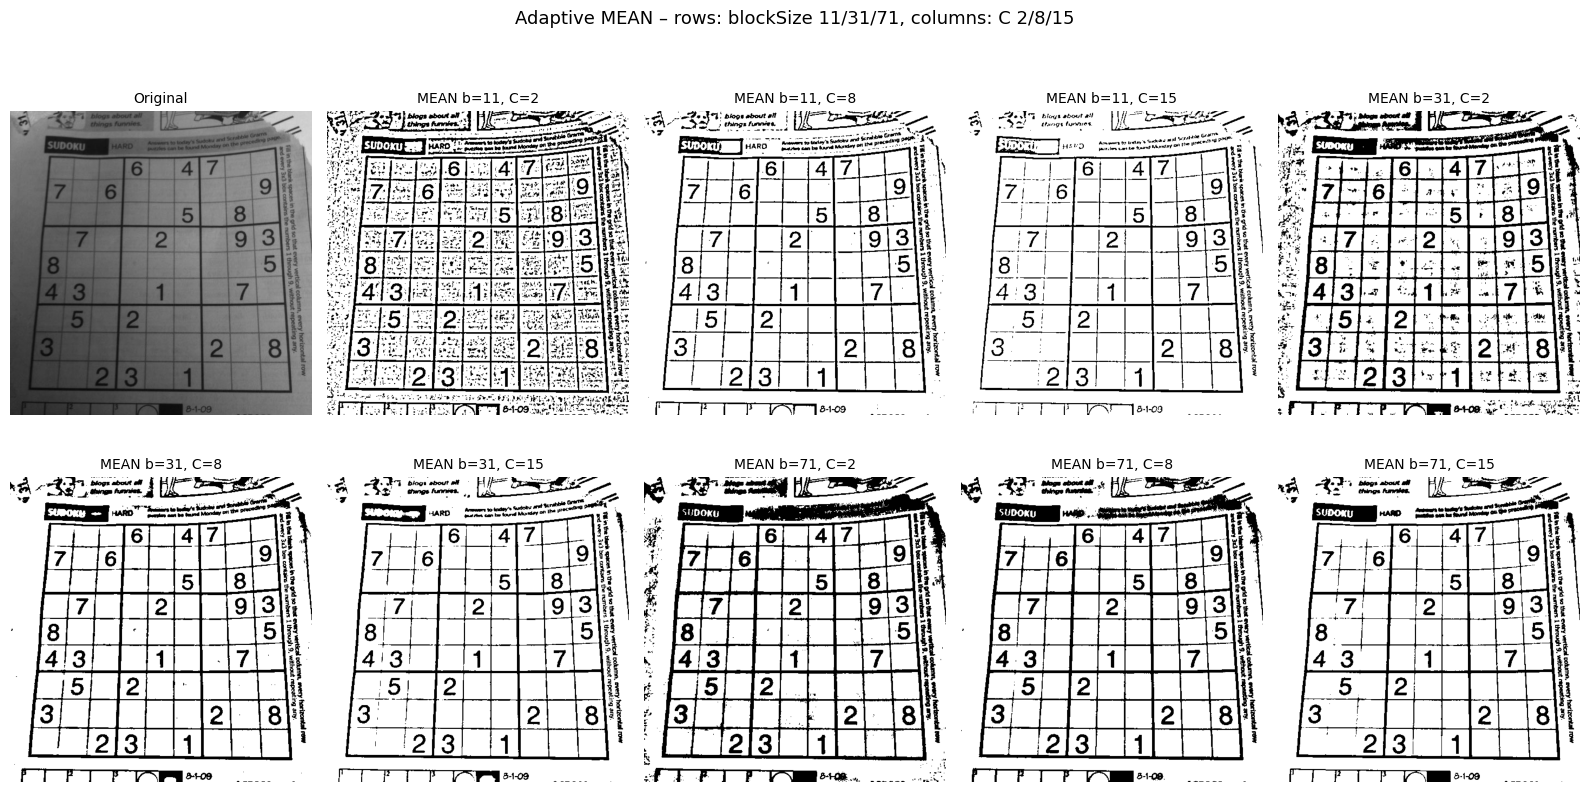

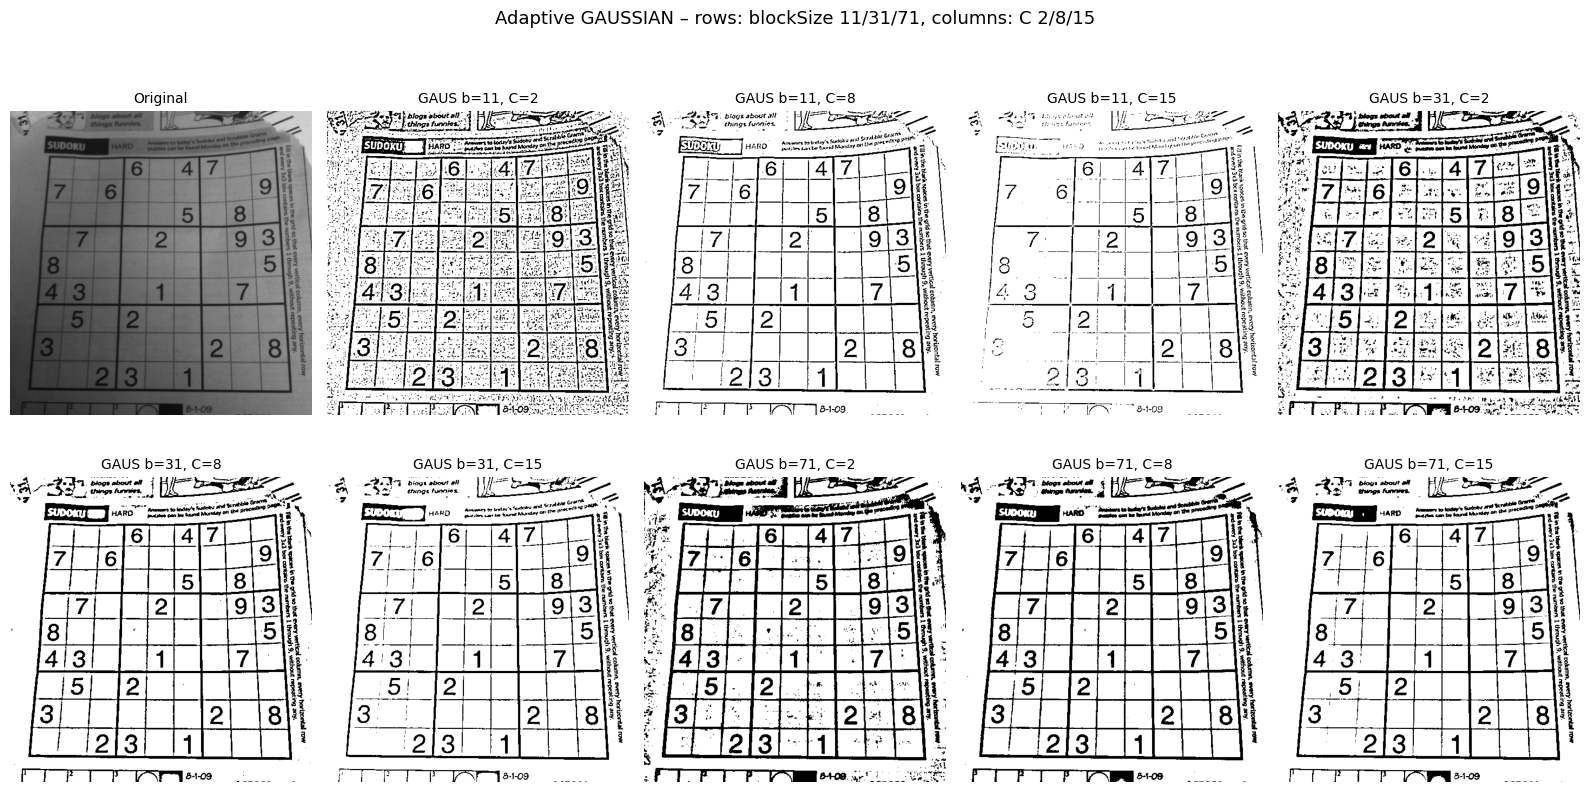

C → noise specks        2      8      15
method   blockSize                      
GAUSSIAN 11         4029.0  186.0  520.0
         31         1238.0  102.0  129.0
         71          522.0   81.0   96.0
MEAN     11         2043.0  170.0  159.0
         31          635.0   96.0   93.0
         71          252.0   84.0   96.0

C → black %            2      8      15
method   blockSize                     
GAUSSIAN 11         22.45  12.20   7.97
         31         23.90  16.31  12.97
         71         23.32  18.26  15.05
MEAN     11         25.65  15.28  11.93
         31         24.89  18.39  15.04
         71         24.57  19.59  16.19

In [4]:
BLOCKS = [11, 31, 71]
CS     = [2, 8, 15]
methods = {"MEAN": cv2.ADAPTIVE_THRESH_MEAN_C, "GAUSSIAN": cv2.ADAPTIVE_THRESH_GAUSSIAN_C}

def noise_stats(mask):
    """mask: text=0 (black). Returns black% and number of tiny black specks (<=8 px) = noise."""
    black = (mask == 0).astype(np.uint8)
    n, lab, st, _ = cv2.connectedComponentsWithStats(black, 8)
    areas = st[1:, cv2.CC_STAT_AREA]
    return 100 * black.mean(), int((areas <= 8).sum()), int(n - 1)

results, records = {}, []
for mname, m in methods.items():
    for b in BLOCKS:
        for c in CS:
            res = cv2.adaptiveThreshold(gray, 255, m, cv2.THRESH_BINARY, b, c)
            results[(mname, b, c)] = res
            bp, specks, comps = noise_stats(res)
            records.append(dict(method=mname, blockSize=b, C=c, black_pct=round(bp, 2), noise_specks=specks, components=comps))
df2 = pd.DataFrame(records)

for mname in methods:
    imgs  = [gray] + [results[(mname, b, c)] for b in BLOCKS for c in CS]
    # show the 9 results of this method (+ original) as 2 rows
    show(imgs, ["Original"] + [f"{mname[:4]} b={b}, C={c}" for b in BLOCKS for c in CS],
         cols=5, w=3.2, h=4.0, save=f"task2_{mname.lower()}_grid.png", suptitle=f"Adaptive {mname} – rows: blockSize 11/31/71, columns: C 2/8/15")
display(df2.pivot_table(index=["method", "blockSize"], columns="C", values="noise_specks").rename_axis(columns="C → noise specks"))
display(df2.pivot_table(index=["method", "blockSize"], columns="C", values="black_pct").rename_axis(columns="C → black %"))

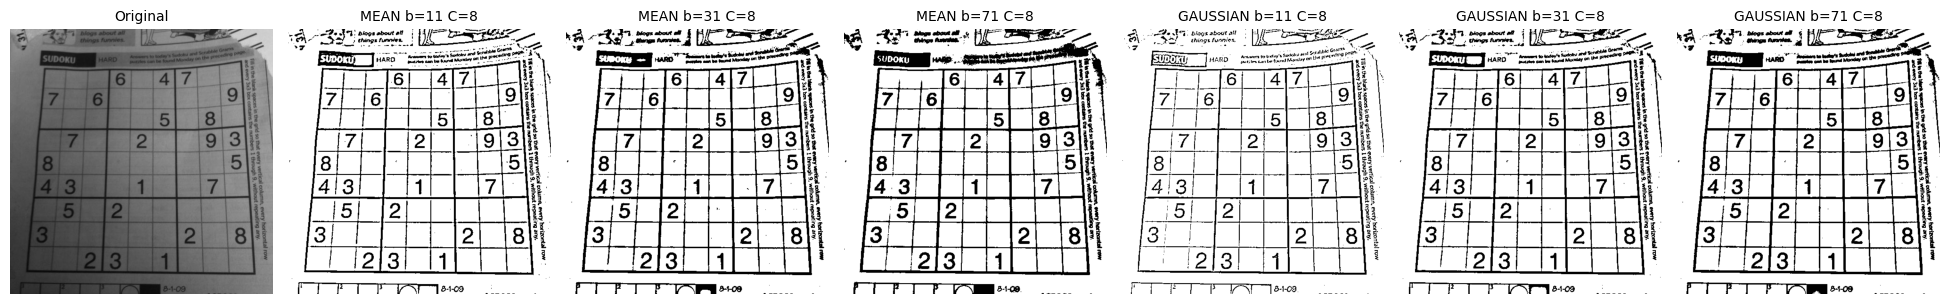

Average noise specks per method over the whole grid:
method
GAUSSIAN    767.0
MEAN        403.0
Chosen combination: ('MEAN', 31, 8)


In [5]:
# Required "original + at least six adaptive results" figure (the most informative six) and final choice
sel = [("MEAN", 11, 8), ("MEAN", 31, 8), ("MEAN", 71, 8), ("GAUSSIAN", 11, 8), ("GAUSSIAN", 31, 8), ("GAUSSIAN", 71, 8)]
show([gray] + [results[k] for k in sel], ["Original"] + [f"{k[0]} b={k[1]} C={k[2]}" for k in sel],
     cols=7, w=2.8, h=3.4, save="task2_six_results.png")
print("Average noise specks per method over the whole grid:")
print(df2.groupby("method")["noise_specks"].mean().round(0).to_string())
# choose among blockSize=31 (window ~ size of a digit/cell) the combination with the fewest specks that still keeps the characters (C<=8)
cand = df2[(df2.blockSize == 31) & (df2.C <= 8)].sort_values("noise_specks")
BEST = (cand.iloc[0].method, int(cand.iloc[0].blockSize), int(cand.iloc[0].C))
save_img("task2_final_best.png", results[BEST])
print("Chosen combination:", BEST)

**Required analysis (Task 2)** – checked against the grids/tables above.
1. **Neighbourhood too small (blockSize 11):** the window is smaller than a character, so the local threshold follows paper texture and the stroke interior. With low C this fills the page with **black speckle noise** (thousands of tiny specks in the table); with high C (15) thin/faint characters become **broken or disappear**.
2. **Neighbourhood too large (blockSize 71):** the window covers a big part of the page and the method starts to behave like a global threshold again: the illumination gradient is tracked poorly, so **dark blobs appear near the shadowed/edge regions** (bottom and top-right of the image) and strokes look heavier.
3. **C increased:** the threshold is `local average − C`, so a pixel must be *darker* than its surroundings by more than C to become text. Higher C → far fewer noise specks and thinner strokes; too high (15 with small windows) → faint characters are lost. Low C (2) → noisy at every block size.
4. **Cleanest text segmentation:** blockSize ≈ **31 with C ≈ 8** (the notebook selects the lowest-noise setting at blockSize 31, C ≤ 8): characters are complete and the paper is clean. blockSize 11/C 8 is also acceptable but leaves more specks; blockSize 71 leaves edge blobs.
5. **Mean vs Gaussian:** on this image the two give **very similar** results at good settings. Mean-based produced fewer isolated specks on average (see the printed averages – mainly at low C), whereas Gaussian (centre-weighted) is a bit more sensitive to pixel noise at low C but follows smooth illumination changes more gracefully; at C ≈ 8 and blockSize ≈ 31 the difference is marginal.

---
## Task 3 – Quality control with Otsu's thresholding

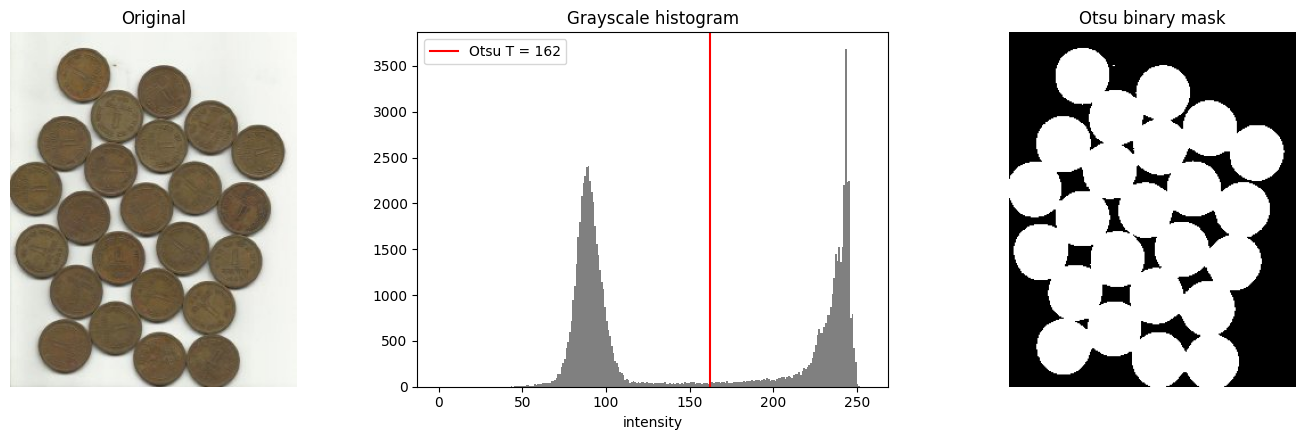

In [6]:
coins_bgr = cv2.imread("coins.jpg")
coins_gray = cv2.cvtColor(coins_bgr, cv2.COLOR_BGR2GRAY)

def otsu(g):
    t, m = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)  # coins darker than background -> white
    return t, m

t0, mask0 = otsu(coins_gray)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(rgb(coins_bgr)); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].hist(coins_gray.ravel(), bins=256, range=(0, 256), color="gray"); ax[1].axvline(t0, color="r", label=f"Otsu T = {t0:.0f}")
ax[1].set_title("Grayscale histogram"); ax[1].set_xlabel("intensity"); ax[1].legend()
ax[2].imshow(mask0, cmap="gray"); ax[2].set_title("Otsu binary mask"); ax[2].axis("off")
plt.tight_layout(); plt.savefig(os.path.join(OUT, "task3_original_hist_otsu.png"), dpi=150); plt.show()
save_img("task3_final_otsu_mask.png", mask0)

,variant,Otsu threshold,foreground %
0,original,162.0,55.9
1,Gaussian blur 5x5,162.0,56.5
2,contrast x1.5 (alpha),162.0,55.2
3,contrast x0.6 (low contrast),117.0,55.9
4,brightness +40,191.0,55.3
5,CLAHE,158.0,55.0


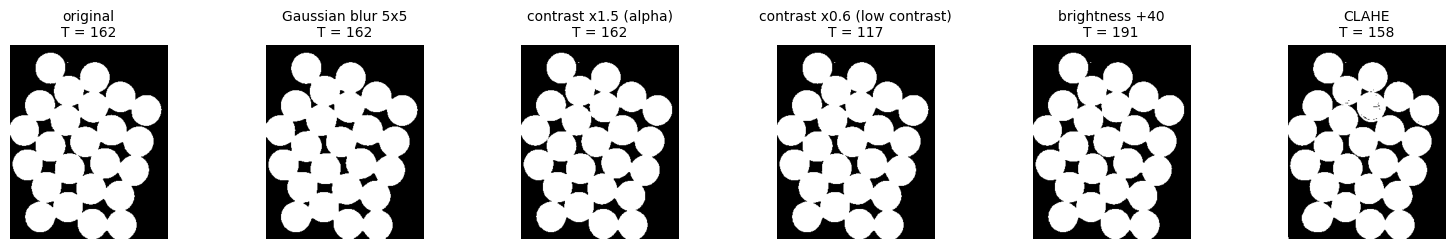

In [7]:
# --- Repeat after changing contrast / preprocessing slightly
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
variants = {
    "original":                    coins_gray,
    "Gaussian blur 5x5":           cv2.GaussianBlur(coins_gray, (5, 5), 0),
    "contrast x1.5 (alpha)":       cv2.convertScaleAbs(coins_gray, alpha=1.5, beta=-60),
    "contrast x0.6 (low contrast)":cv2.convertScaleAbs(coins_gray, alpha=0.6, beta=20),
    "brightness +40":              cv2.convertScaleAbs(coins_gray, alpha=1.0, beta=40),
    "CLAHE":                       clahe.apply(coins_gray),
}
rows_v, imgs, tits = [], [], []
for name, g in variants.items():
    t, m = otsu(g)
    rows_v.append({"variant": name, "Otsu threshold": round(float(t), 1), "foreground %": round(100 * (m > 0).mean(), 1)})
    imgs.append(m); tits.append(f"{name}\nT = {t:.0f}")
display(pd.DataFrame(rows_v))
show(imgs, tits, cols=6, w=2.6, save="task3_variants.png")

**Parameters:** Otsu (`THRESH_BINARY_INV + THRESH_OTSU`, threshold argument is ignored and computed automatically). `INV` is used because the coins are darker than the background and we want the objects to be white.

**Comparison:** blur barely moves T (it only smooths the histogram); brightness/contrast changes shift or scale T because the whole histogram moves – yet the *resulting foreground mask stays almost the same*, because Otsu moves the threshold with the histogram.

**Why is Otsu useful when the programmer does not know the correct threshold beforehand?**
Otsu searches all 256 possible thresholds and picks the one that maximises the between-class variance (equivalently minimises within-class variance) of the object and background pixel classes. It only needs a roughly bimodal histogram (object + background) and no manual tuning, so it adapts automatically when the camera exposure, lighting level or contrast changes from one image to the next – ideal for a quality-control system that processes many images.

---
## Task 4 – Sorting objects by colour (HSV segmentation)
OpenCV HSV ranges: H 0–179, S 0–255, V 0–255. Target colour: **green smartie** (change `TARGET` to try other colours).

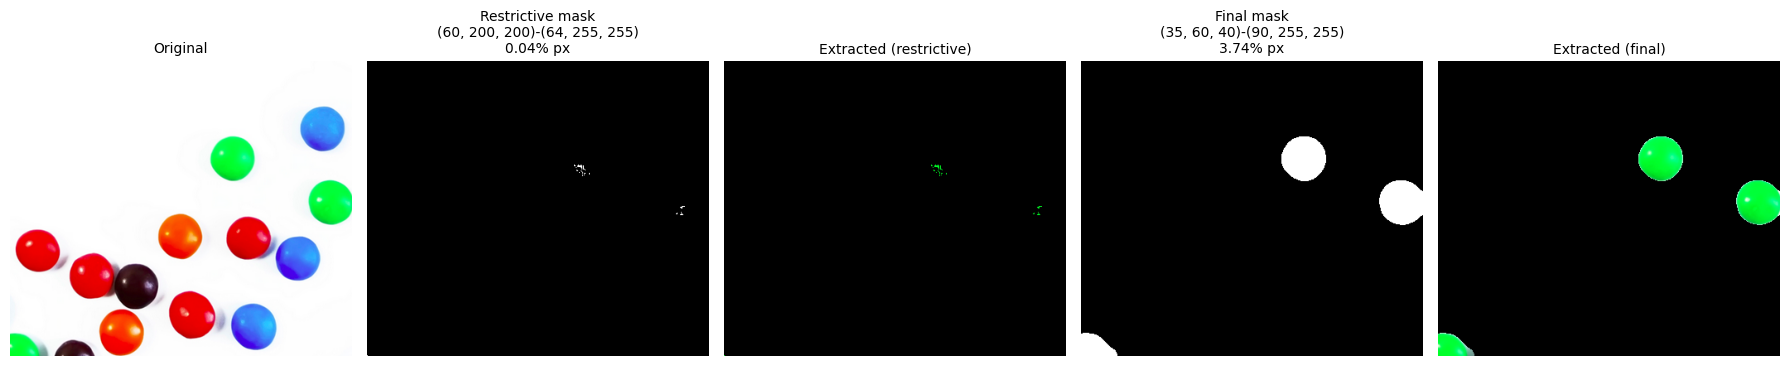

,mask,lower,upper,mask px,blobs
0,restrictive,"(60, 200, 200)","(64, 255, 255)",64,16
1,widen H only,"(35, 200, 200)","(90, 255, 255)",4968,3
2,widen H+S,"(35, 60, 200)","(90, 255, 255)",5382,5
3,"final (H,S,V wide)","(35, 60, 40)","(90, 255, 255)",5483,3


In [8]:
smart_bgr = cv2.imread("smarties.png")
hsv = cv2.cvtColor(smart_bgr, cv2.COLOR_BGR2HSV)

# (lower, upper) pairs.  "restrictive" is deliberately too tight; "final" is the tuned range.
PRESETS = {
    "green": dict(restrictive=((60, 200, 200), (64, 255, 255)),  final=((35, 60, 40), (90, 255, 255))),
    "blue":  dict(restrictive=((110, 200, 200), (114, 255, 255)), final=((95, 60, 40), (135, 255, 255))),
    "orange":dict(restrictive=((12, 200, 200), (14, 255, 255)),  final=((5, 100, 100), (25, 255, 255))),
}
TARGET = "green"
(lo_r, hi_r), (lo_f, hi_f) = PRESETS[TARGET]["restrictive"], PRESETS[TARGET]["final"]

mask_restrictive = cv2.inRange(hsv, np.array(lo_r), np.array(hi_r))
mask_final_raw   = cv2.inRange(hsv, np.array(lo_f), np.array(hi_f))
# small closing fills the specular highlights inside the candy
mask_final = cv2.morphologyEx(mask_final_raw, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))

ext_restrictive = cv2.bitwise_and(smart_bgr, smart_bgr, mask=mask_restrictive)
ext_final       = cv2.bitwise_and(smart_bgr, smart_bgr, mask=mask_final)

def pct(m): return f"{100*(m>0).mean():.2f}% px"
show([rgb(smart_bgr), mask_restrictive, rgb(ext_restrictive), mask_final, rgb(ext_final)],
     ["Original", f"Restrictive mask\n{lo_r}-{hi_r}\n{pct(mask_restrictive)}", "Extracted (restrictive)",
      f"Final mask\n{lo_f}-{hi_f}\n{pct(mask_final)}", "Extracted (final)"],
     cols=5, w=3.6, save="task4_hsv_result.png")
save_img("task4_final_mask.png", mask_final)
save_img("task4_final_extracted.png", ext_final)

# experiment table: gradually widen the limits from "restrictive" to "final"
lo_a, hi_a = np.array(lo_r), np.array(hi_r); lo_b, hi_b = np.array(lo_f), np.array(hi_f)
steps = {"restrictive": (lo_a, hi_a),
         "widen H only": (np.array([lo_b[0], lo_a[1], lo_a[2]]), np.array([hi_b[0], hi_a[1], hi_a[2]])),
         "widen H+S": (np.array([lo_b[0], lo_b[1], lo_a[2]]), np.array([hi_b[0], hi_b[1], hi_a[2]])),
         "final (H,S,V wide)": (lo_b, hi_b)}
exps = []
for name, (lo, hi) in steps.items():
    m = cv2.inRange(hsv, lo, hi)
    exps.append({"mask": name, "lower": tuple(int(v) for v in lo), "upper": tuple(int(v) for v in hi),
                 "mask px": int((m > 0).sum()), "blobs": cv2.connectedComponents(m, connectivity=8)[0] - 1})
display(pd.DataFrame(exps))

**Parameters & justification:** green sits around H ≈ 60 in OpenCV's 0–179 scale, so the final range uses H 35–90. `S ≥ 60` rejects the white background and the pale highlights (white has S≈0), `V ≥ 40` rejects very dark shadows. A 7×7 closing fills specular highlights.

**Why does the restrictive mask fail?**
It keeps only a 4-unit hue band (H 60–64, while the candy's hue is centred near 67 and spreads over 64–81) *and* only high saturation/brightness, but a real candy is a 3-D shiny object: the shading makes hue, saturation and value vary across its surface (darker/less saturated at the edges, bright specular highlight with S≈0 in the middle). Only a tiny core of pixels (sometimes almost none – see the pixel counts in the table) falls inside the narrow box, so the candy is represented by a few tiny fragments instead of one solid region. Widening H, then S and V (table rows) progressively recovers the whole candy. HSV helps because hue is separated from brightness, but the *limits* still have to be wide enough to cover the natural variation of the object.

---
## Task 5 – Boundary detection with Canny (hysteresis thresholding)

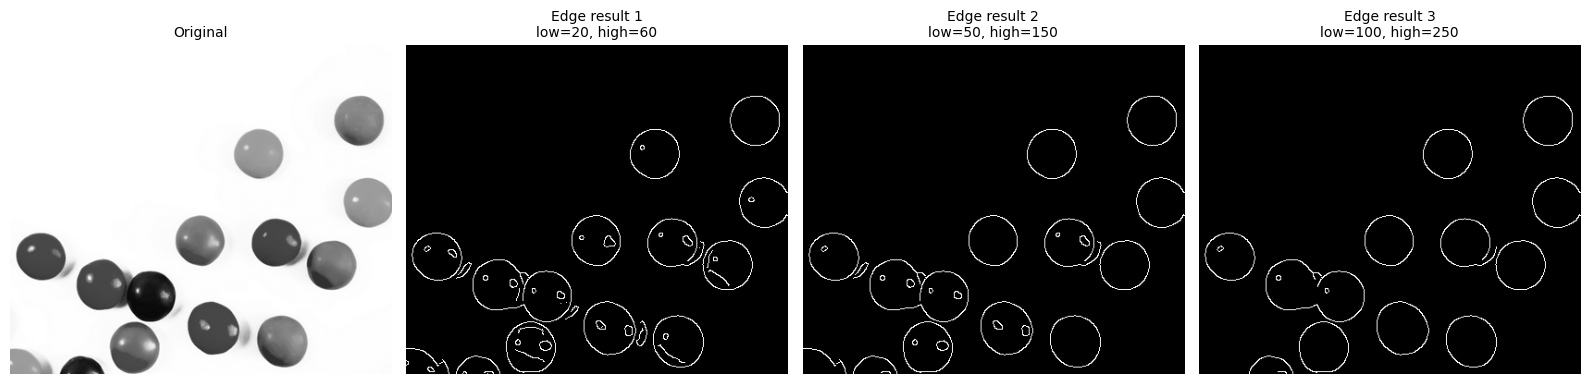

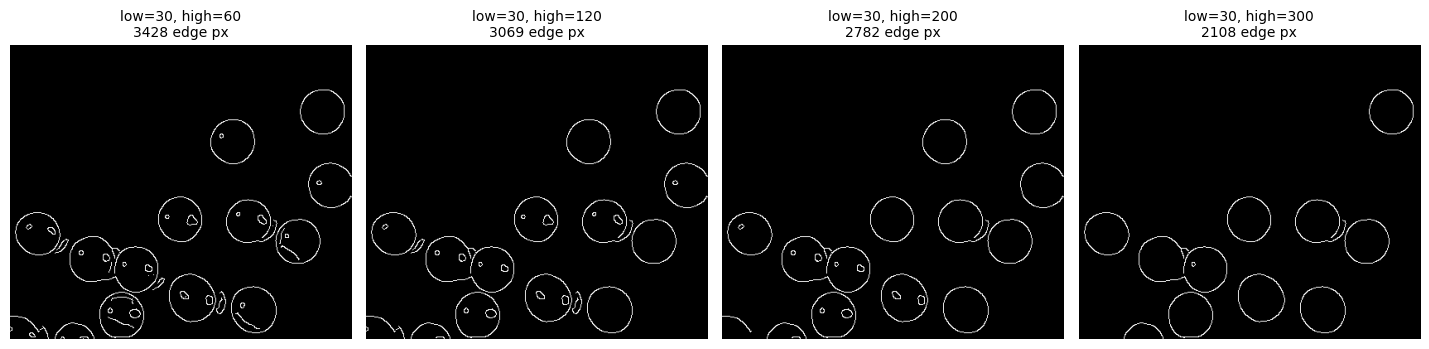

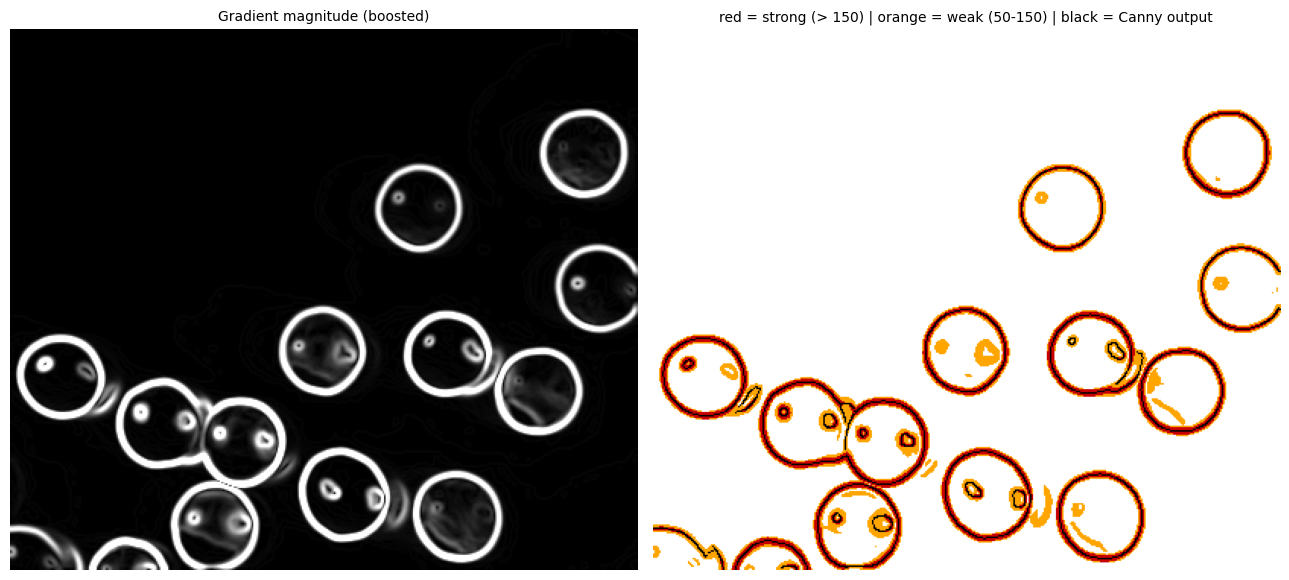

,low,high,edge pixels
0,20,60,3433
1,50,150,2917
2,100,250,2495


In [9]:
g5 = cv2.cvtColor(smart_bgr, cv2.COLOR_BGR2GRAY)
g5b = cv2.GaussianBlur(g5, (5, 5), 1.4)          # noise reduction before gradient computation

PAIRS = [(20, 60), (50, 150), (100, 250)]        # (low, high)
edges = [cv2.Canny(g5b, lo, hi, L2gradient=True) for lo, hi in PAIRS]
show([g5] + edges, ["Original"] + [f"Edge result {i+1}\nlow={lo}, high={hi}" for i, (lo, hi) in enumerate(PAIRS)],
     cols=4, w=4, save="task5_canny_comparison.png")
save_img("task5_final_edges.png", edges[1])

# extra: keep LOW fixed, increase HIGH
FIX_LOW = 30
series = [cv2.Canny(g5b, FIX_LOW, h, L2gradient=True) for h in (60, 120, 200, 300)]
show(series, [f"low={FIX_LOW}, high={h}\n{int((e>0).sum())} edge px" for h, e in zip((60, 120, 200, 300), series)],
     cols=4, w=3.6, save="task5_fixed_low_series.png")

# Visualising the hysteresis idea on pair 2: Sobel gradient magnitude split in strong / weak
gx = cv2.Sobel(g5b, cv2.CV_32F, 1, 0, ksize=3); gy = cv2.Sobel(g5b, cv2.CV_32F, 0, 1, ksize=3)
mag = np.sqrt(gx**2 + gy**2)
lo, hi = PAIRS[1]
vis = np.full(g5.shape + (3,), 255, np.uint8)
vis[(mag > lo) & (mag <= hi)] = (255, 165, 0)     # weak candidates (orange)
vis[mag > hi] = (200, 0, 0)                        # strong edges (red)
vis[edges[1] > 0] = (0, 0, 0)                      # final Canny output (black thin lines)
show([np.clip(mag / mag.max() * 255 * 3, 0, 255).astype(np.uint8), vis],
     ["Gradient magnitude (boosted)", f"red = strong (> {hi}) | orange = weak ({lo}-{hi}) | black = Canny output"],
     cols=2, w=6.5, save="task5_hysteresis_view.png")
display(pd.DataFrame({"low": [p[0] for p in PAIRS], "high": [p[1] for p in PAIRS], "edge pixels": [int((e > 0).sum()) for e in edges]}))

**Classification of edges (see figures):**
- **Strong edges** – the outlines of the high-contrast candies against the white background (gradient above `high`); they survive in all three settings.
- **Weak edges** – soft shadows next to the candies, the specular highlight rim and the low-contrast outline of the dark/pale candies; their gradient lies between `low` and `high`. Hysteresis keeps them **only if connected to a strong edge**.
- **Missing edges** – appear when `high` is too large (pair 3: parts of the boundary of low-contrast candies break or vanish).
- **Unwanted edges** – appear when `low/high` are too small (pair 1: shadows, JPEG/background noise, highlight contours).

**How the two thresholds change the result:** `high` decides which pixels are *trusted seeds* for an edge; `low` decides how far an edge may *extend* from those seeds along weaker pixels. Raising `high` with `low` fixed removes whole weak edges (nothing to start from) and breaks contours; lowering `low` makes edges longer and connected but lets noise attach to them; the best result keeps a ratio of about 1:2–1:3 (pair 2).

---
## Task 6 – Region growing on a brain MRI
The notebook tries `skimage.data.brain()` (a real brain MRI) first. If it cannot be downloaded, upload any brain-MRI slice as `brain.png`; otherwise a synthetic phantom is used so the code still runs.

MRI source: skimage.data.brain() – middle slice (256, 256)
Seeds (row, col): {'seed A (bright area)': (86, 143), 'seed B (dark area)': (68, 102)} | intensities: {'seed A (bright area)': 69, 'seed B (dark area)': 7}


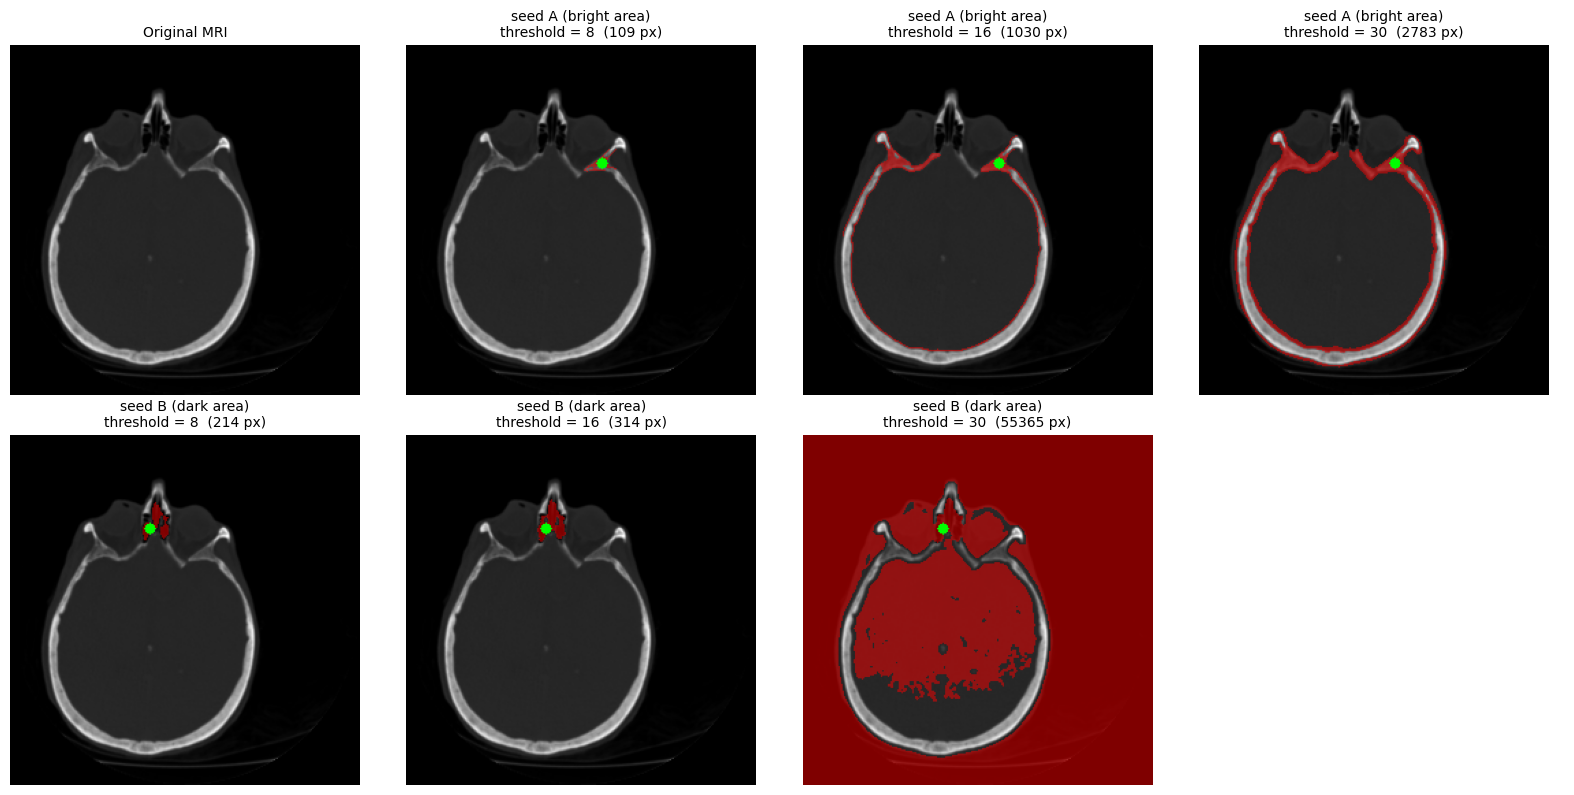

,seed,"pos (r,c)",threshold,region px
0,seed A (bright area),"(86, 143)",8,109
1,seed A (bright area),"(86, 143)",16,1030
2,seed A (bright area),"(86, 143)",30,2783
3,seed B (dark area),"(68, 102)",8,214
4,seed B (dark area),"(68, 102)",16,314
5,seed B (dark area),"(68, 102)",30,55365


In [14]:
import subprocess, sys
try:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pooch'], check=False, capture_output=True)   # needed by skimage to fetch sample data
    from skimage import data as skdata
    vol = skdata.brain()                        # (slices, 256, 256) uint16 MRI volume
    sl = vol[vol.shape[0] // 2].astype(np.float32)
    mri = cv2.normalize(sl, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    MRI_SOURCE = "skimage.data.brain() – middle slice"
except Exception as e:
    mri = None
    if os.path.exists("brain_2.png"):
        mri = cv2.imread("brain_2.png", 0); MRI_SOURCE = "uploaded brain.png"
if mri is None:
    # synthetic phantom fallback (so the pipeline is always runnable)
    mri = np.zeros((256, 256), np.uint8)
    cv2.ellipse(mri, (128, 128), (100, 115), 0, 0, 360, 140, -1)      # brain tissue
    cv2.ellipse(mri, (128, 128), (100, 115), 0, 0, 360, 200, 6)       # skull ring
    cv2.ellipse(mri, (105, 120), (14, 32), 20, 0, 360, 60, -1)        # ventricle L
    cv2.ellipse(mri, (151, 120), (14, 32), -20, 0, 360, 60, -1)       # ventricle R
    cv2.circle(mri, (150, 175), 18, 190, -1)                           # bright lesion
    mri = cv2.GaussianBlur(mri, (5, 5), 1.5)
    mri = np.clip(mri.astype(np.int16) + np.random.RandomState(0).normal(0, 6, mri.shape), 0, 255).astype(np.uint8)
    MRI_SOURCE = "synthetic phantom (fallback)"
print("MRI source:", MRI_SOURCE, mri.shape)

smooth = cv2.GaussianBlur(mri, (5, 5), 0)       # suppress noise before comparing intensities

def region_grow(img, seed, thr, connectivity=8, compare_to="seed"):
    """BFS region growing. A neighbour joins if |I(neighbour) - reference| <= thr.
    reference = mean of a 5x5 patch around the seed ("seed") or the running region mean ("mean")."""
    h, w = img.shape
    sy, sx = seed
    ref = float(img[max(sy-2, 0):sy+3, max(sx-2, 0):sx+3].mean())
    mask = np.zeros((h, w), np.uint8); mask[sy, sx] = 255
    q = deque([(sy, sx)]); total, cnt = ref, 1
    nbrs = [(-1,0),(1,0),(0,-1),(0,1)] + ([(-1,-1),(-1,1),(1,-1),(1,1)] if connectivity == 8 else [])
    while q:
        y, x = q.popleft()
        for dy, dx in nbrs:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] == 0:
                r = ref if compare_to == "seed" else total / cnt
                v = float(img[ny, nx])
                if abs(v - r) <= thr:
                    mask[ny, nx] = 255; q.append((ny, nx)); total += v; cnt += 1
    return mask

# --- choose two seed points (automatic defaults; edit SEED_A / SEED_B as (row, col) after looking at the image)
brain_mask = cv2.threshold(smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
otsu_t = cv2.threshold(smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0]
head = ((smooth > 0.5 * otsu_t) * 255).astype(np.uint8)
cnts, _ = cv2.findContours(head, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
brain_mask = np.zeros_like(head)
if cnts: cv2.drawContours(brain_mask, [max(cnts, key=cv2.contourArea)], -1, 255, -1)
brain_mask = cv2.erode(brain_mask, np.ones((31, 31), np.uint8))
if brain_mask.sum() == 0:
    h_, w_ = mri.shape; brain_mask[h_//4:3*h_//4, w_//4:3*w_//4] = 255
sm_big = cv2.GaussianBlur(mri, (0, 0), 6).astype(np.float32)
inside = brain_mask > 0
SEED_A = tuple(int(v) for v in np.unravel_index(np.argmax(np.where(inside, sm_big, -np.inf)), sm_big.shape))
SEED_B = tuple(int(v) for v in np.unravel_index(np.argmin(np.where(inside, sm_big,  np.inf)), sm_big.shape))
SEEDS = {"seed A (bright area)": SEED_A, "seed B (dark area)": SEED_B}
THRS = [8, 16, 30]
print("Seeds (row, col):", SEEDS, "| intensities:", {k: int(smooth[v]) for k, v in SEEDS.items()})

imgs, tits, rec = [], [], []
for sname, sd in SEEDS.items():
    for t in THRS:
        m = region_grow(smooth, sd, t)
        ov = cv2.cvtColor(mri, cv2.COLOR_GRAY2RGB); ov[m > 0] = (0.5 * ov[m > 0] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
        cv2.circle(ov, (sd[1], sd[0]), 4, (0, 255, 0), -1)
        imgs.append(ov); tits.append(f"{sname}\nthreshold = {t}  ({int((m>0).sum())} px)")
        rec.append({"seed": sname, "pos (r,c)": sd, "threshold": t, "region px": int((m > 0).sum())})
        if sname.startswith("seed A") and t == THRS[1]: save_img("task6_final_mask.png", m)
show([cv2.cvtColor(mri, cv2.COLOR_GRAY2RGB)] + imgs, ["Original MRI"] + tits, cols=4, w=4, save="task6_region_growing.png")
display(pd.DataFrame(rec))

**Parameters:** 8-connectivity; membership test `|I(neighbour) − I(seed patch mean)| ≤ T` with T = 8 / 16 / 30; Gaussian 5×5 pre-smoothing so that single noisy pixels do not stop the growth. Two seeds: one in a bright region, one in a dark one (edit `SEED_A`, `SEED_B` to choose your own anatomical locations).

**Why can changing the seed point significantly change the final region?**
Region growing is *seed-dependent*: the acceptance criterion is measured against the intensity of the seed (patch). A seed in a different tissue has a different reference intensity, so the set of pixels within ±T of it is a completely different set, and growth can only spread through pixels that are *connected* to the seed – tissue of the same intensity that is separated by a boundary is never reached. A seed placed on noise, an edge or a partial-volume pixel gives an unrepresentative reference and either leaks into neighbouring tissue or stops almost immediately. Larger thresholds make this worse (leakage through weak boundaries); smaller ones fragment the region.

---
## Task 7 – Marker-based watershed: separating touching coins

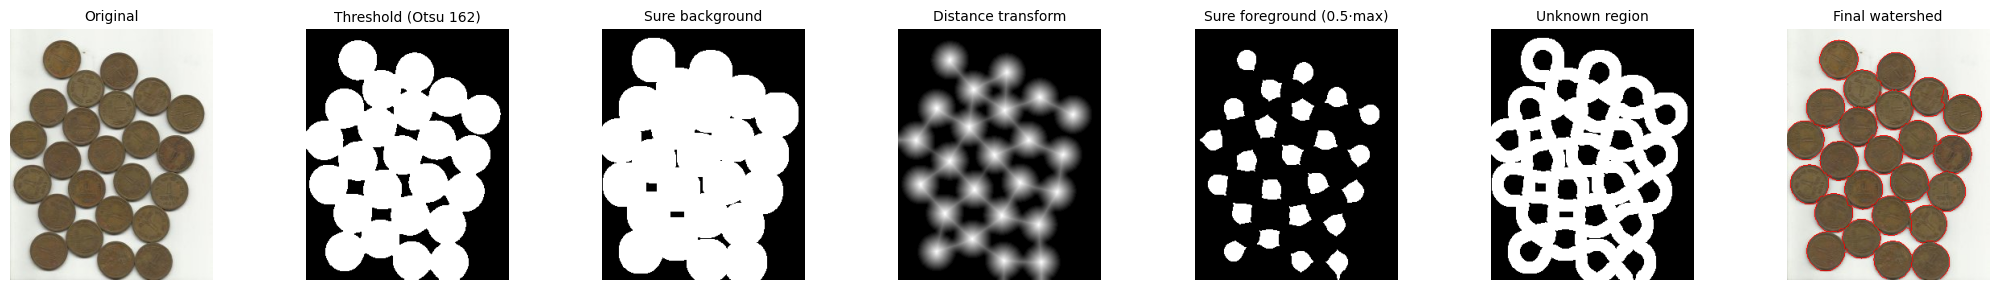

Connected components of the plain threshold : 1
Foreground markers                          : 24
Regions after watershed (= coins counted)   : 24


In [15]:
def watershed_pipeline(bgr, dt_ratio=0.5, open_iter=2, dilate_iter=3):
    """Full marker-based watershed. Returns a dict with every intermediate stage."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)                                              # 1 preprocessing
    thr_val, thr = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)   # 2 thresholding
    k = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(thr, cv2.MORPH_OPEN, k, iterations=open_iter)               # 3 noise removal
    sure_bg = cv2.dilate(opened, k, iterations=dilate_iter)                               # 4 sure background
    dist = cv2.distanceTransform(opened, cv2.DIST_L2, 5)                                  # 5 distance transform
    _, sure_fg = cv2.threshold(dist, dt_ratio * dist.max(), 255, 0)                       # 6 sure foreground
    sure_fg = sure_fg.astype(np.uint8)
    unknown = cv2.subtract(sure_bg, sure_fg)                                              # 7 unknown region
    n_fg, markers = cv2.connectedComponents(sure_fg)                                      # 8 marker labelling
    markers = markers + 1                      # background = 1, objects = 2..n
    markers[unknown == 255] = 0                # unknown = 0 -> watershed decides
    markers = cv2.watershed(bgr.copy(), markers)                                          # 9 watershed
    bnd = (markers == -1); bnd[[0, -1], :] = False; bnd[:, [0, -1]] = False       # ignore the image frame
    out = bgr.copy(); out[bnd] = (0, 0, 255)                                    # 10 boundaries (red)
    labels = np.unique(markers); labels = labels[labels > 1]
    return dict(gray=gray, thr=thr, thr_val=thr_val, opened=opened, sure_bg=sure_bg, dist=dist, sure_fg=sure_fg,
                unknown=unknown, markers=markers, out=out, n_markers=n_fg - 1, n_regions=len(labels))

r7 = watershed_pipeline(coins_bgr, dt_ratio=0.5)
dist_vis = cv2.normalize(r7["dist"], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
show([rgb(coins_bgr), r7["thr"], r7["sure_bg"], dist_vis, r7["sure_fg"], r7["unknown"], rgb(r7["out"])],
     ["Original", f"Threshold (Otsu {r7['thr_val']:.0f})", "Sure background", "Distance transform", "Sure foreground (0.5·max)", "Unknown region", "Final watershed"],
     cols=7, w=3.0, save="task7_pipeline.png")
save_img("task7_final_watershed.png", r7["out"])

naive = cv2.connectedComponents(r7["opened"])[0] - 1
print(f"Connected components of the plain threshold : {naive}")
print(f"Foreground markers                          : {r7['n_markers']}")
print(f"Regions after watershed (= coins counted)   : {r7['n_regions']}")

**Visual inspection:** in the plain threshold, touching coins form one connected white blob, so connected-component counting under-counts. After the distance transform, each coin has its own bright peak; thresholding it gives one separate sure-foreground marker per coin, and watershed floods from these markers so that the red boundary lines pass through the necks between touching coins. Check in the last image that every coin is enclosed by its own boundary.

**Parameters:** Gaussian 5×5 blur (noise), Otsu threshold (automatic), opening 3×3 ×2 (removes specks), dilation ×3 (sure background), `DIST_L2` mask 5, sure-foreground threshold = **0.5 × max(distance)** (central half of each coin).

---
## Task 8 – Tuning the distance-transform threshold

,Experiment,Distance Threshold,Foreground markers,Regions,Observed Result
0,1,0.20·max = 4.8,1,1,UNDER-segmented: ~23 coin(s) merged or lost
1,2,0.40·max = 9.6,7,7,UNDER-segmented: ~17 coin(s) merged or lost
2,3,0.60·max = 14.4,24,24,"all 24 coins separated, uniform regions (CV=0.04)"
3,4,0.80·max = 19.2,24,24,"all 24 coins separated, uniform regions (CV=0.04)"
4,5,0.95·max = 22.8,24,24,count OK (24) but very uneven region sizes (CV=0.51) - markers too small
5,6,0.99·max = 23.8,20,20,UNDER-segmented: ~4 coin(s) merged or lost


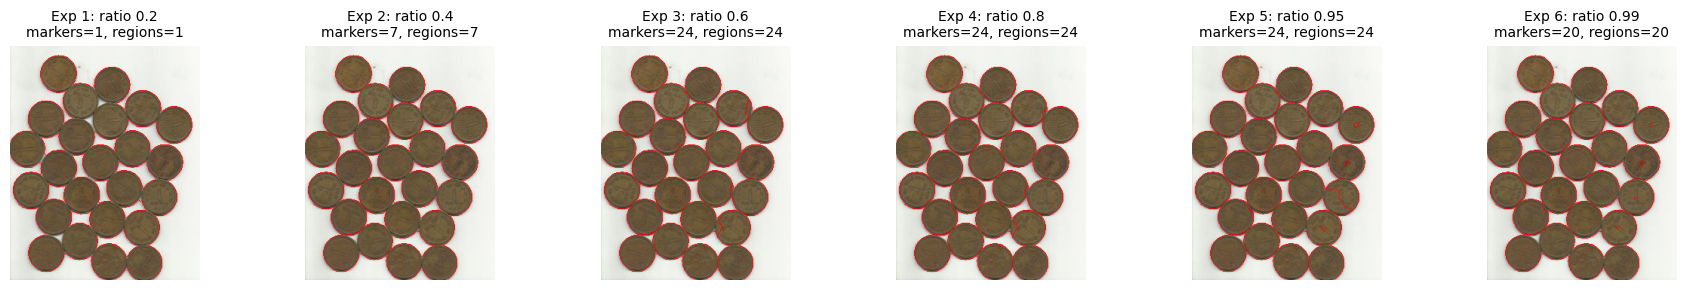

Reference coin count (most frequent result): 24
Ratios that separate every coin with uniform regions: [0.6, 0.8]


In [16]:
RATIOS = [0.20, 0.40, 0.60, 0.80, 0.95, 0.99]       # fraction of max(distance transform)
runs = []
for ratio in RATIOS:
    r = watershed_pipeline(coins_bgr, dt_ratio=ratio)
    areas = np.bincount(r["markers"][r["markers"] > 1])[2:]; areas = areas[areas > 0]
    runs.append((ratio, r, float(areas.std() / areas.mean()) if len(areas) > 1 else 0.0))

REF = pd.Series([r["n_regions"] for _, r, _ in runs]).mode().max()    # most frequent count (= the 24 coins you can count by eye)
rows8, imgs8, tit8 = [], [], []
for i, (ratio, r, cv) in enumerate(runs, 1):
    n = r["n_regions"]
    if n < REF:   obs = f"UNDER-segmented: ~{REF - n} coin(s) merged or lost"
    elif n > REF: obs = f"OVER-segmented: {n - REF} extra region(s)"
    elif cv > 0.2: obs = f"count OK ({REF}) but very uneven region sizes (CV={cv:.2f}) - markers too small"
    else:         obs = f"all {REF} coins separated, uniform regions (CV={cv:.2f})"
    rows8.append({"Experiment": i, "Distance Threshold": f"{ratio:.2f}·max = {ratio*r['dist'].max():.1f}",
                  "Foreground markers": r["n_markers"], "Regions": n, "Observed Result": obs, "_ok": (n == REF) * (1 - min(cv, 1))})
    imgs8.append(rgb(r["out"])); tit8.append(f"Exp {i}: ratio {ratio}\nmarkers={r['n_markers']}, regions={n}")
df8 = pd.DataFrame(rows8)
pd.set_option("display.max_colwidth", 120); display(df8.drop(columns="_ok"))
show(imgs8, tit8, cols=6, w=3.0, save="task8_experiments.png")

good = [RATIOS[i] for i in range(len(RATIOS)) if df8.loc[i, "_ok"] > 0.8]
print(f"Reference coin count (most frequent result): {REF}")
print("Ratios that separate every coin with uniform regions:", good)
df8.drop(columns="_ok").to_csv(os.path.join(OUT, "task8_table.csv"), index=False)

**Interpretation (checked against the table above, 24 coins in the image):**
- **Ratio ≈ 0.2 (too low):** almost the whole thresholded blob counts as "sure foreground", so the markers of touching coins fuse – the notebook finds a **single marker/region** for the whole group (all coins merged).
- **Ratio ≈ 0.4 (still too low):** only part of the coins separate (7 regions) – the necks between several coins are still "sure foreground".
- **Ratio ≈ 0.6–0.8 (best range):** each coin gets exactly one compact marker → **24 markers, 24 regions, uniform region sizes** – the most meaningful separation. (The plateau actually starts at ≈ 0.45 and lasts to ≈ 0.9.)
- **Ratio ≥ 0.95 (too high):** only the very centre of each coin is kept; first the region sizes become very uneven (markers too small, boundaries unreliable), and at 0.99 some smaller coins **lose their marker** completely (fewer regions).

This confirms that the marker/distance-transform stage is the critical one: watershed only floods from the markers it is given, so too few/merged markers → merged coins, too tiny markers → missed/unreliable coins.

---
## Task 9 – K-Means colour segmentation (K = 2, 4, 6)
Uses `dog.jpeg` if you upload it to Colab (left file panel); otherwise OpenCV's wildlife sample (`baboon.jpg`) is used.

Image: baboon.jpg (512, 512, 3)


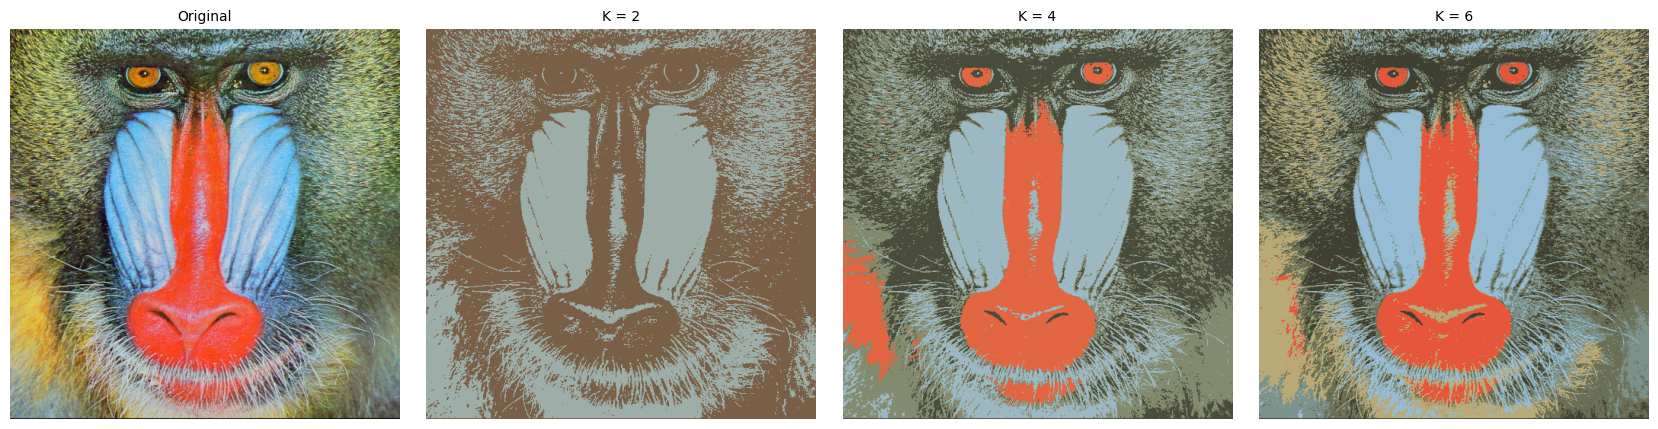

,K (clusters),unique colours (orig -> seg),MSE vs original,compactness,major regions (colour share)
0,2,171045 -> 2,1639.0,1288586327,orange 57%; gray 43%
1,4,171045 -> 4,694.5,545974863,yellow 32%; cyan 26%; dark yellow 26%; red 15%
2,6,171045 -> 6,463.9,364591572,yellow 23%; light cyan 18%; dark orange 17%; orange 16%; gray 15%; red 12%


In [17]:
if os.path.exists("dog.jpeg"):
    km_path = "dog.jpeg"
else:
    km_path = fetch("baboon.jpg", [RAW + "baboon.jpg"])
img9 = cv2.imread(km_path)
if max(img9.shape[:2]) > 600:                          # keep K-Means fast
    s = 600 / max(img9.shape[:2]); img9 = cv2.resize(img9, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
print("Image:", km_path, img9.shape)

def color_name(bgr):
    h, s, v = cv2.cvtColor(np.uint8([[bgr]]), cv2.COLOR_BGR2HSV)[0, 0]
    if v < 50: return "black/very dark"
    if s < 40: return "white/light gray" if v > 190 else "gray"
    hue = ["red", "orange", "yellow", "green", "cyan", "blue", "purple", "magenta/red"][int(((h * 2) + 22.5) // 45) % 8]
    return ("dark " if v < 110 else "light " if v > 200 and s < 120 else "") + hue

pixels = img9.reshape(-1, 3).astype(np.float32)                 # 1) reshape  2) float32
crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
orig_colors = len(np.unique(img9.reshape(-1, 3), axis=0))

res9, rows9, imgs9, tit9 = {}, [], [rgb(img9)], ["Original"]
for K in (2, 4, 6):
    compactness, labels, centers = cv2.kmeans(pixels, K, None, crit, 5, cv2.KMEANS_PP_CENTERS)   # 3) cluster
    centers = np.uint8(centers)                                                                  # 4) centers
    seg = centers[labels.flatten()].reshape(img9.shape)                                          # 5) reconstruct
    res9[K] = seg; imgs9.append(rgb(seg)); tit9.append(f"K = {K}")
    share = np.bincount(labels.flatten(), minlength=K) / len(labels) * 100
    mse = float(np.mean((seg.astype(np.float32) - img9.astype(np.float32)) ** 2))
    regions = "; ".join(f"{color_name(c)} {p:.0f}%" for c, p in sorted(zip(centers, share), key=lambda x: -x[1]))
    rows9.append({"K (clusters)": K, "unique colours (orig -> seg)": f"{orig_colors} -> {len(np.unique(seg.reshape(-1,3), axis=0))}",
                  "MSE vs original": round(mse, 1), "compactness": round(float(compactness)), "major regions (colour share)": regions})
    save_img(f"task9_kmeans_K{K}.png", seg)
show(imgs9, tit9, cols=4, w=4.2, save="task9_kmeans_comparison.png")
pd.set_option("display.max_colwidth", 200); display(pd.DataFrame(rows9))

**Workflow followed (as in the manual):** reshape the image to an N×3 matrix → convert to `float32` → `cv2.kmeans` (k-means++ initialisation, 5 attempts, 20 iterations / ε = 1) → convert centres to `uint8` → replace every pixel by its cluster centre and reshape back.

**Observations:** K = 2 gives a poster-like two-tone image (only a light/dark split; maximum simplification, largest error). K = 4 keeps the main colour regions listed in the table but merges subtle shading. K = 6 is visually closest to the original with only 6 colours; the MSE column decreases as K grows, while the number of colours (and therefore the simplification) shrinks. Smooth gradients turn into flat patches with visible borders – these borders are the "segments".

---
## Task 10 – Segmentation engineer: three approaches on one challenging image
Image: **smarties.png** (coloured candies, soft shadows, touching/near-touching objects, a dark brown candy on a white background).  
Methods: **(1) Otsu thresholding, (2) HSV colour thresholding, (3) marker-based watershed.**

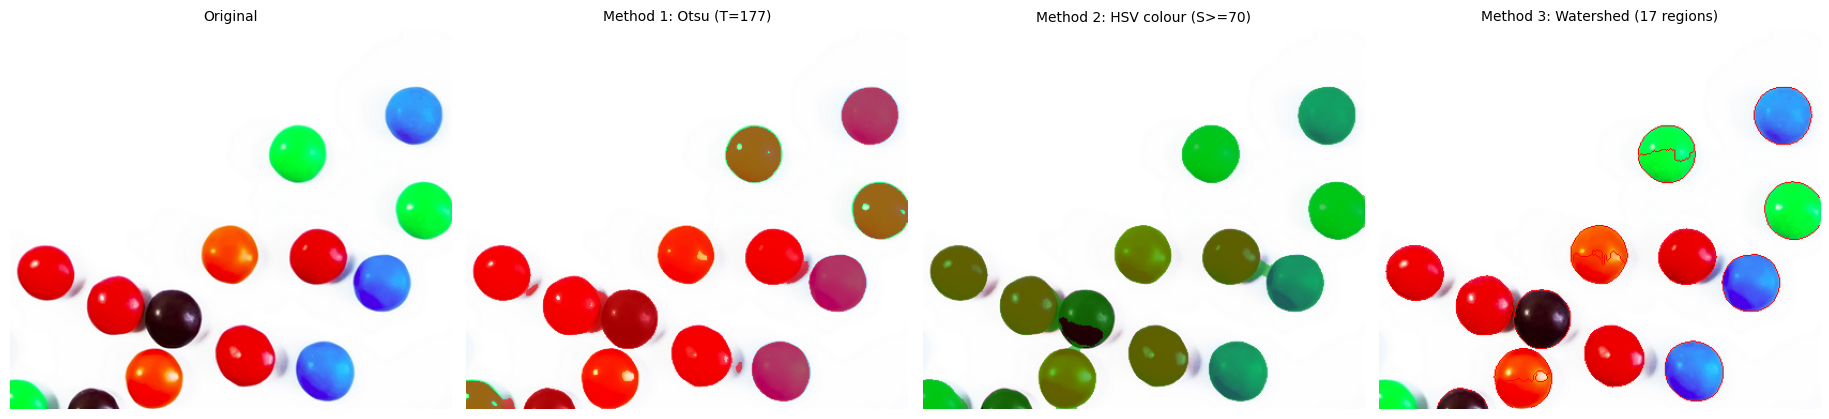

,method,objects (blobs),foreground %,dark brown candy found?,objects counted vs ~14 by eye
0,Otsu,13,19.7,True,13 / 14
1,HSV colour,12,19.7,True,12 / 14
2,Watershed,17,18.1,True,17 / 14


,parameter,value,foreground %,objects
0,Otsu T offset,-30.0,15.652801,12
1,Otsu T offset,-15.0,18.827026,13
2,Otsu T offset,0.0,19.702370,13
3,Otsu T offset,15.0,20.355987,13
4,Otsu T offset,30.0,21.025927,11
5,HSV S_min,20.0,20.976957,10
6,HSV S_min,50.0,20.060805,11
7,HSV S_min,70.0,19.716653,12
8,HSV S_min,110.0,19.056234,13
9,HSV S_min,150.0,18.321680,13


Spread of object count / foreground-% per parameter:


,objects_range,fg_pct_range
parameter,,
HSV S_min,3,2.7
Otsu T offset,2,5.4
Watershed DT ratio,13,13.1


In [18]:
img10 = cv2.imread("smarties.png"); g10 = cv2.cvtColor(img10, cv2.COLOR_BGR2GRAY)
hsv10 = cv2.cvtColor(img10, cv2.COLOR_BGR2HSV)

def count_blobs(m, min_area=80):
    n, _, st, _ = cv2.connectedComponentsWithStats((m > 0).astype(np.uint8), 8)
    return int((st[1:, cv2.CC_STAT_AREA] >= min_area).sum())

# ---- Method 1: Otsu on the blurred gray image
def m_otsu(offset=0):
    b = cv2.GaussianBlur(g10, (5, 5), 0)
    t, _ = cv2.threshold(b, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return cv2.threshold(b, t + offset, 255, cv2.THRESH_BINARY_INV)[1], t

# ---- Method 2: HSV colour thresholding (all strongly coloured pixels)
def m_hsv(s_min=70, v_min=40):
    m = cv2.inRange(hsv10, np.array((0, s_min, v_min)), np.array((179, 255, 255)))
    return cv2.morphologyEx(m, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))

# ---- Method 3: watershed (re-uses the Task 7 pipeline)
def m_ws(ratio=0.5):
    r = watershed_pipeline(img10, dt_ratio=ratio)
    return r

mask1, t_otsu = m_otsu(); mask2 = m_hsv(); r3 = m_ws(0.5)
mask3 = ((r3["markers"] > 1)).astype(np.uint8) * 255
ov1 = img10.copy(); ov1[mask1 > 0] = (0.4 * ov1[mask1 > 0] + 0.6 * np.array([0, 0, 255])).astype(np.uint8)
ov2 = img10.copy(); ov2[mask2 > 0] = (0.4 * ov2[mask2 > 0] + 0.6 * np.array([0, 160, 0])).astype(np.uint8)

show([rgb(img10), rgb(ov1), rgb(ov2), rgb(r3["out"])],
     ["Original", f"Method 1: Otsu (T={t_otsu:.0f})", "Method 2: HSV colour (S>=70)", f"Method 3: Watershed ({r3['n_regions']} regions)"],
     cols=4, w=4.6, save="task10_final_comparison.png")
save_img("task10_otsu_mask.png", mask1); save_img("task10_hsv_mask.png", mask2); save_img("task10_watershed.png", r3["out"])

# ---- Evidence for the analysis: counts and parameter sensitivity
dark_candy = hsv10[..., 2] < 90        # very dark pixels = brown candy (low S, low V)
N_TRUE = 14   # candies visible in the image counted by eye (11 complete + 3 partly cut off at the border)
summary = pd.DataFrame([
    {"method": "Otsu", "objects (blobs)": count_blobs(mask1), "foreground %": round(100*(mask1>0).mean(), 1),
     "dark brown candy found?": bool(((mask1 > 0) & dark_candy).sum() > 0.5 * dark_candy.sum())},
    {"method": "HSV colour", "objects (blobs)": count_blobs(mask2), "foreground %": round(100*(mask2>0).mean(), 1),
     "dark brown candy found?": bool(((mask2 > 0) & dark_candy).sum() > 0.5 * dark_candy.sum())},
    {"method": "Watershed", "objects (blobs)": r3["n_regions"], "foreground %": round(100*(mask3>0).mean(), 1),
     "dark brown candy found?": bool(((mask3 > 0) & dark_candy).sum() > 0.5 * dark_candy.sum())}])
summary["objects counted vs ~14 by eye"] = summary["objects (blobs)"].astype(int).astype(str) + " / " + str(N_TRUE)
display(summary)

sens = []
for off in (-30, -15, 0, 15, 30):
    m, _ = m_otsu(off); sens.append(("Otsu T offset", off, 100*(m>0).mean(), count_blobs(m)))
for s in (20, 50, 70, 110, 150):
    m = m_hsv(s_min=s); sens.append(("HSV S_min", s, 100*(m>0).mean(), count_blobs(m)))
for ra in (0.2, 0.4, 0.5, 0.7, 0.9):
    rr = m_ws(ra); sens.append(("Watershed DT ratio", ra, 100*((rr["markers"]>1).mean()), rr["n_regions"]))
sens = pd.DataFrame(sens, columns=["parameter", "value", "foreground %", "objects"])
display(sens)
print("Spread of object count / foreground-% per parameter:")
display(sens.groupby("parameter").agg(objects_range=("objects", lambda x: x.max()-x.min()),
                                      fg_pct_range=("foreground %", lambda x: round(x.max()-x.min(), 1))))

**Required analysis per method** (written from the images and tables above – re-check after your run):

| | 1. Assumption about the image | 2. Successfully identifies | 3. Incorrectly segments | 4. Parameter with greatest effect |
|---|---|---|---|---|
| **Otsu** | Gray-level histogram is bimodal: candies are darker than the white background | Almost all candies as complete, solid blobs (including the dark brown one), with no manual threshold | Specular highlights / pale spots become small holes; faint shadow halos can be included; **touching/near-touching candies would merge**; it says nothing about colour | the threshold value (automatic) – changing it ±30 only changes the foreground by a few % (see sensitivity table) |
| **HSV colour** | Candies differ from the white background and gray shadows by *saturation* | The chromatic candies; shadows (unsaturated) are ignored | Highlights (S ≈ 0) and the dark brown candy centre leave **holes**; neighbouring candies still merge; some pieces are lost when `S_min` is too high | `S_min` (saturation limit) |
| **Watershed** | Each object is a compact blob with **one** distance-transform peak | Gives one numbered region *per object* (countable) and separates touching blobs | **Over-segments**: highlights/shape irregularities create extra markers (17 regions vs ≈14 candies); with a high ratio candies lose their markers (count falls to 4–7) | distance-transform ratio – by far the most sensitive (object count range ≈ 13 in the table) |

### Technical conclusion
Based on the observed results, **Otsu thresholding produced the most meaningful regions for this image**: the candies are bright, saturated or dark objects on a uniform near-white background, so a single automatically chosen gray-level threshold already isolates all of them (13 of ≈14 blobs) as clean solid masks with almost no parameter sensitivity. HSV thresholding gave a similar mask but loses pixels where saturation is low (highlights, dark candy) and depends on `S_min`; watershed was the *least* suitable here – the candies are not actually touching, so its main advantage (splitting touching objects) is not needed, and the specular highlights violate its "one peak per object" assumption, producing extra regions and a strong dependence on the distance-transform ratio. The deciding image properties were therefore (a) strong foreground/background intensity contrast with a uniform background and (b) well-separated, convex objects. If the candies were touching, watershed would become the better choice; if only one colour were wanted, HSV would.

---
## Save everything

In [19]:
zip_name = "lab05_outputs.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(os.listdir(OUT)): z.write(os.path.join(OUT, f), f)
print("Saved files:"); [print("  ", f) for f in sorted(os.listdir(OUT))]
try:
    from google.colab import files
    files.download(zip_name)
except Exception:
    print("(Not in Colab – find", zip_name, "in the working directory)")

Saved files:
   task10_final_comparison.png
   task10_hsv_mask.png
   task10_otsu_mask.png
   task10_watershed.png
   task1_comparison.png
   task1_failure_map.png
   task1_final_adaptive_mask.png
   task2_final_best.png
   task2_gaussian_grid.png
   task2_mean_grid.png
   task2_six_results.png
   task3_final_otsu_mask.png
   task3_original_hist_otsu.png
   task3_variants.png
   task4_final_extracted.png
   task4_final_mask.png
   task4_hsv_result.png
   task5_canny_comparison.png
   task5_final_edges.png
   task5_fixed_low_series.png
   task5_hysteresis_view.png
   task6_final_mask.png
   task6_region_growing.png
   task7_final_watershed.png
   task7_pipeline.png
   task8_experiments.png
   task8_table.csv
   task9_kmeans_K2.png
   task9_kmeans_K4.png
   task9_kmeans_K6.png
   task9_kmeans_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>